In [1]:
import pandas as pd
import requests
import librosa
import os
import time
from tqdm import tqdm
import IPython.display as ipd

# 1. โหลดไฟล์ต้นฉบับ
file_path = 'C:/Users/66982/OneDrive/Desktop/BOTNOI_AutoQC/Email1.csv'
df_ori = pd.read_csv(file_path, encoding='utf-8-sig')

# สร้างคอลัมน์ audio_index ขึ้นมาใหม่ โดยเริ่มที่ 0, 1, 2...
df_ori['audio_index'] = df_ori.index


# สร้างโฟลเดอร์สำหรับเก็บไฟล์เสียง (ถ้ายังไม่มี)
temp_audio_path = 'temp_audio'
if not os.path.exists(temp_audio_path):
    os.makedirs(temp_audio_path)

print(f"📊 โหลดข้อมูลมาทั้งหมด {len(df_ori)} แถวเรียบร้อย")

📊 โหลดข้อมูลมาทั้งหมด 7071 แถวเรียบร้อย


In [2]:
#Cell 2: Define Functions
def classify_qc(trim_dur, ratio, text):
    """ฟังก์ชันตัดสินสถานะตามเกณฑ์ใหม่ 3.65 และเช็ก NaN"""
    if pd.isna(text) or str(text).strip().lower() == 'nan':
        return "Abnormal: Text Missing"
    if trim_dur < 0.5:
        return "Abnormal: Too Short"
    if ratio > 3.65:
        return "Abnormal: Too Fast"
    if ratio < 0.5:
        return "Abnormal: Too Slow"
    return "Passed"

def download_with_retry(url, dest, retries=2):
    """ฟังก์ชันโหลดไฟล์พร้อมระบบลองใหม่ (Retry)"""
    for i in range(retries + 1):
        try:
            resp = requests.get(url, timeout=15)
            if resp.status_code == 200:
                with open(dest, 'wb') as f:
                    f.write(resp.content)
                return True
        except:
            if i < retries: time.sleep(1) # รอ 1 วินาทีก่อนลองใหม่
    return False

In [3]:
import numpy as np
import openpyxl

# --- ตั้งค่าเริ่มต้น ---
batch_size = 550
total_rows = len(df_ori) # จะได้ 7071 แถว
output_filename = 'C:/Users/66982/OneDrive/Desktop/BOTNOI_AutoQC/QC_Results_Batch.xlsx'
all_results_list = [] # List สำหรับเก็บ DataFrame ของแต่ละ Batch

print(f"🚀 เริ่มประมวลผลทั้งหมด {total_rows} แถว (แบ่งเป็นรอบละ {batch_size} แถว)...")

# วนลูปใหญ่ตามจำนวน Batch
for start_idx in range(0, total_rows, batch_size):
    end_idx = min(start_idx + batch_size, total_rows)
    df_batch = df_ori.iloc[start_idx:end_idx].copy()
    
    print(f"\n📦 กำลังรัน Batch: {start_idx} ถึง {end_idx}")

    # วนลูปย่อยในแต่ละ Batch
    for index, row in tqdm(df_batch.iterrows(), total=len(df_batch), desc=f"Progress {start_idx}-{end_idx}"):
        audio_idx = row['audio_index']
        text = row['text']
        url = row['audio']
        local_path = os.path.join(temp_audio_path, f"audio_{audio_idx}.wav")
        
        # 1. เช็ก NaN
        if pd.isna(text) or str(text).strip().lower() == 'nan':
            status, current_path, trim_dur, ratio = "Abnormal: Text Missing", "NaN (No Audio)", 0, 0
        else:
            # 2. ดาวน์โหลด (Retry 2 ครั้ง)
            if download_with_retry(url, local_path):
                try:
                    # 3. ประมวลผลเสียง
                    y, sr = librosa.load(local_path, sr=None)
                    y_trimmed, _ = librosa.effects.trim(y, top_db=25)
                    trim_dur = librosa.get_duration(y=y_trimmed, sr=sr)
                    word_count = len(str(text).split())
                    ratio = word_count / trim_dur if trim_dur > 0 else 0
                    
                    # 4. ตัดสินสถานะ (3.65)
                    status = classify_qc(trim_dur, ratio, text)
                    
                    # 5. ลบไฟล์ปกติทิ้งทันที
                    if status == "Passed":
                        if os.path.exists(local_path): os.remove(local_path)
                        current_path = "Deleted (Passed)"
                    else:
                        current_path = local_path
                except:
                    status, current_path, trim_dur, ratio = "Error: Processing Failed", local_path, 0, 0
            else:
                status, current_path, trim_dur, ratio = "Error: Download Failed", "N/A", 0, 0

        # อัปเดตข้อมูลลงใน DataFrame Batch
        df_batch.loc[index, 'word_count'] = len(str(text).split()) if pd.notna(text) else 0
        df_batch.loc[index, 'trim_duration'] = round(trim_dur, 2)
        df_batch.loc[index, 'ratio'] = round(ratio, 2)
        df_batch.loc[index, 'qc_status'] = status
        df_batch.loc[index, 'local_path'] = current_path

    # เก็บ DataFrame ที่ทำเสร็จแล้วของ Batch นี้ลงใน List
    all_results_list.append(df_batch)

    # รวม List ทั้งหมดที่มีตอนนี้แล้วเซฟทับไฟล์เดิม (กันพลาดถ้าคอมดับ)
    df_combined = pd.concat(all_results_list, ignore_index=True)
    df_combined.to_excel(output_filename, index=False)
    print(f"💾 บันทึกความคืบหน้าลงไฟล์ {output_filename} (รวมแล้ว {len(df_combined)} แถว)")

print(f"\n🎉 เสร็จสมบูรณ์ทั้งหมด {total_rows} แถว! ไฟล์เดียวจบที่: {output_filename}")

🚀 เริ่มประมวลผลทั้งหมด 7071 แถว (แบ่งเป็นรอบละ 550 แถว)...

📦 กำลังรัน Batch: 0 ถึง 550


Progress 0-550: 100%|██████████| 550/550 [40:15<00:00,  4.39s/it]


💾 บันทึกความคืบหน้าลงไฟล์ C:/Users/66982/OneDrive/Desktop/BOTNOI_AutoQC/QC_Results_Batch.xlsx (รวมแล้ว 550 แถว)

📦 กำลังรัน Batch: 550 ถึง 1100


Progress 550-1100: 100%|██████████| 550/550 [31:18<00:00,  3.42s/it]


💾 บันทึกความคืบหน้าลงไฟล์ C:/Users/66982/OneDrive/Desktop/BOTNOI_AutoQC/QC_Results_Batch.xlsx (รวมแล้ว 1100 แถว)

📦 กำลังรัน Batch: 1100 ถึง 1650


...

💾 บันทึกความคืบหน้าลงไฟล์ C:/Users/66982/OneDrive/Desktop/BOTNOI_AutoQC/QC_Results_Batch.xlsx (รวมแล้ว 6050 แถว)

📦 กำลังรัน Batch: 6050 ถึง 6600


Progress 6050-6600: 100%|██████████| 550/550 [32:18<00:00,  3.52s/it]


💾 บันทึกความคืบหน้าลงไฟล์ C:/Users/66982/OneDrive/Desktop/BOTNOI_AutoQC/QC_Results_Batch.xlsx (รวมแล้ว 6600 แถว)

📦 กำลังรัน Batch: 6600 ถึง 7071


Progress 6600-7071: 100%|██████████| 471/471 [27:14<00:00,  3.47s/it]


💾 บันทึกความคืบหน้าลงไฟล์ C:/Users/66982/OneDrive/Desktop/BOTNOI_AutoQC/QC_Results_Batch.xlsx (รวมแล้ว 7071 แถว)

🎉 เสร็จสมบูรณ์ทั้งหมด 7071 แถว! ไฟล์เดียวจบที่: C:/Users/66982/OneDrive/Desktop/BOTNOI_AutoQC/QC_Results_Batch.xlsx


Visualization

C:\Users\66982\AppData\Local\Temp\ipykernel_3996\2169248358.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='ratio', y=speaker_col, ax=ax2, palette='Set3', fliersize=4)


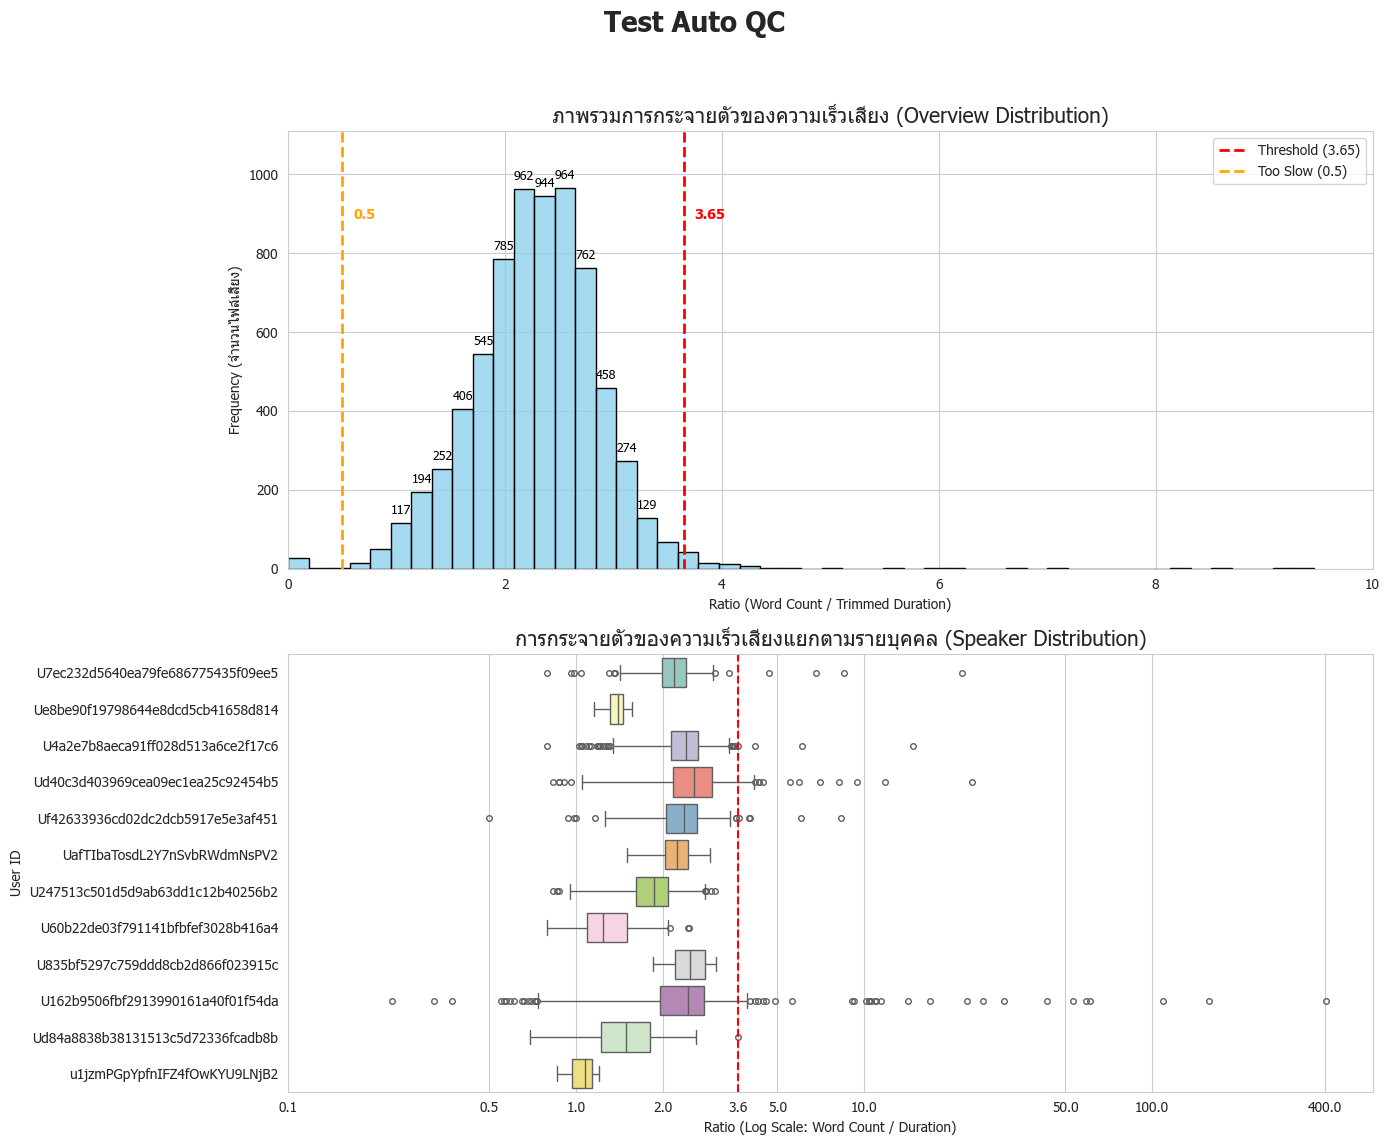

✅ พล็อตกราฟและบันทึกไฟล์ 'QC_Distribution_Report.png' เรียบร้อย


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. โหลดข้อมูล
file_path = 'C:/Users/66982/OneDrive/Desktop/BOTNOI_AutoQC/QC_Results_Batch.xlsx'
df_final = pd.read_excel(file_path)

# --- ฟอนต์ภาษาไทย ---
plt.rcParams['font.family'] = 'Tahoma' 
plt.rcParams['axes.unicode_minus'] = False # ป้องกันเครื่องหมายลบเพี้ยน

# สร้างพื้นที่แสดงผล 2 กราฟ (บน-ล่าง)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))
fig.suptitle('Test Auto QC', fontsize=20, fontweight='bold')

# -------------------------------------------------------
# กราฟที่ 1: Distribution ภาพรวม 
# -------------------------------------------------------
df_plot = df_final[(df_final['ratio'] >= 0) & (df_final['ratio'] <= 10)]

# ใช้ df_plot แทน df_final ในการวาดกราฟแรก
sns.histplot(df_plot['ratio'], bins=50, color='skyblue', ax=ax1, edgecolor='black', stat='count')
# --- ใส่ตัวเลขกำกับบนแท่ง (เพิ่มต่อจาก sns.histplot) ---
for p in ax1.patches:
    height = p.get_height()
    if height > 100:  # เลือกแสดงเฉพาะแท่งที่มีจำนวนไฟล์ > 100 ไฟล์ เพื่อไม่ให้รกเกินไป
        ax1.annotate(f'{int(height)}', 
                     (p.get_x() + p.get_width() / 2., height), 
                     ha = 'center', va = 'center', 
                     xytext = (0, 9), 
                     textcoords = 'offset points',
                     fontsize=9, color='black')

# ปรับเพดานแกน Y ให้สูงขึ้นนิดหน่อยเพื่อให้มีที่ว่างวางตัวเลข
ax1.set_ylim(0, max([p.get_height() for p in ax1.patches]) * 1.15)

threshold_fast = 3.65
threshold_slow = 0.5
ax1.axvline(3.65, color='red', linestyle='--', linewidth=2, label='Threshold (3.65)')
ax1.text(threshold_fast + 0.1, ax1.get_ylim()[1]*0.8, f'{threshold_fast}', color='red', fontweight='bold')
ax1.axvline(0.5, color='orange', linestyle='--', linewidth=2, label='Too Slow (0.5)')
ax1.text(threshold_slow + 0.1, ax1.get_ylim()[1]*0.8, f'{threshold_slow}', color='orange', fontweight='bold')

ax1.set_xlim(0, 10)
ax1.set_title('ภาพรวมการกระจายตัวของความเร็วเสียง (Overview Distribution)', fontsize=15)
ax1.set_xlabel('Ratio (Word Count / Trimmed Duration)')
ax1.set_ylabel('Frequency (จำนวนไฟล์เสียง)')
ax1.legend()

# -------------------------------------------------------
# กราฟที่ 2: Distribution รายคน (Boxplot)
# -------------------------------------------------------
speaker_col = df_final.columns[10] 

# พล็อตทุกคนที่มีชื่อปรากฏ
sns.boxplot(data=df_final, x='ratio', y=speaker_col, ax=ax2, palette='Set3', fliersize=4)

# ปรับแกน X เป็น Log Scale
ax2.set_xscale('log')
ax2.axvline(3.65, color='red', linestyle='--', linewidth=1.5)

# ปรับคำอธิบายแกน X ให้ดูง่ายขึ้นในแบบ Log
from matplotlib.ticker import ScalarFormatter
ax2.xaxis.set_major_formatter(ScalarFormatter())
ax2.set_xticks([0.1, 0.5, 1, 2, 3.65, 5, 10, 50, 100, 400]) # กำหนดจุดเลขที่อยากให้โชว์

ax2.set_title('การกระจายตัวของความเร็วเสียงแยกตามรายบุคคล (Speaker Distribution)', fontsize=15)
ax2.set_xlabel('Ratio (Log Scale: Word Count / Duration)')
ax2.set_ylabel('User ID')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# 3. บันทึกรูปภาพไว้ไปใส่ใน Slide หรือส่งใน LINE
#plt.savefig('QC_Distribution_Report.png', dpi=300)
plt.show()

print("✅ พล็อตกราฟและบันทึกไฟล์ 'QC_Distribution_Report.png' เรียบร้อย")